# Dataset — Encyclopedic-VQA test subset

1000 examples. Here we look at question types, answer formats, and a few sample images.

In [1]:
import json, os
from collections import Counter
import matplotlib.pyplot as plt

BASE = '/work/cvcs2026/encyclopedic'
data = json.load(open(BASE + '/encyclopedic_test_subset.json'))
print('examples:', len(data))

for field in data[0].keys():
    print(f"field: {field}, type: {type(data[0][field])}")

examples: 1000
field: wikipedia_title, type: <class 'str'>
field: wikipedia_url, type: <class 'str'>
field: question_original, type: <class 'str'>
field: question, type: <class 'str'>
field: question_type, type: <class 'str'>
field: answer, type: <class 'str'>
field: evidence, type: <class 'str'>
field: evidence_section_id, type: <class 'str'>
field: evidence_section_title, type: <class 'str'>
field: dataset_name, type: <class 'str'>
field: dataset_category_id, type: <class 'str'>
field: wikipedia_url_used_in_train, type: <class 'str'>
field: encyclopedic_vqa_split, type: <class 'str'>
field: dataset_image_ids, type: <class 'str'>
field: related_images, type: <class 'str'>
field: retrieval, type: <class 'list'>
field: unique_id, type: <class 'str'>


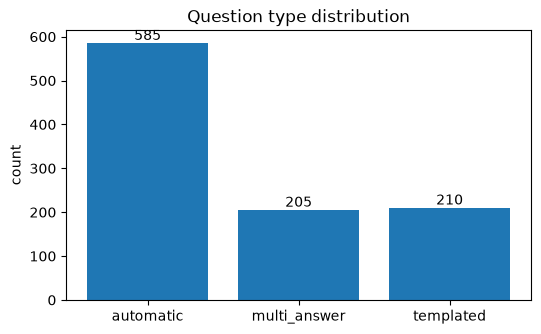

In [2]:
c = Counter(x['question_type'] for x in data)
plt.figure(figsize=(6, 3.5))
plt.bar(list(c.keys()), list(c.values()))
for i, (k, v) in enumerate(c.items()):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.title('Question type distribution'); plt.ylabel('count')
plt.show()

### Answer format: multi_answer uses '&&' to join several gold answers

In [3]:
multi = sum('&&' in str(x['answer']) for x in data)
empty = sum(not str(x.get('answer', '')).strip() for x in data)
print('answers with && (multi):', multi)
print('empty answers:', empty)
print('example automatic  :', repr(data[0]['answer']))
ex = next(x for x in data if x['question_type'] == 'multi_answer')
print('example multi_answer:', repr(ex['answer'])[:120])

templated = next(x for x in data if x['question_type'] == 'templated')
print('example templated:', repr(templated['answer'])[:120])

answers with && (multi): 204
empty answers: 0
example automatic  : 'North American populations'
example multi_answer: 'Texas&&New Mexico&&Virginia&&Florida&&Georgia&&Alabama&&South Carolina&&Mississippi|Texas&&New Mexico&&Virginia&&Florid
example templated: '1.9 cm-6.4 cm|1.9-6.4 cm|1.9 cm - 6.4 cm'


### Sample images with their question / gold answer

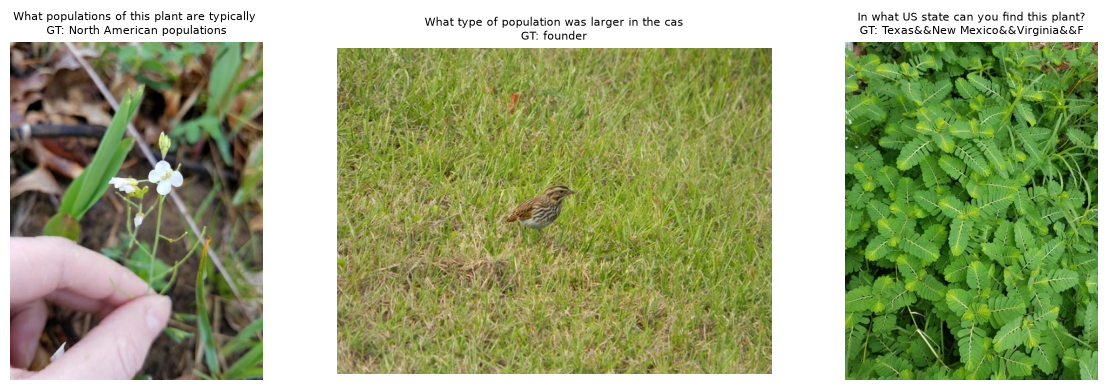

In [4]:
from PIL import Image
samples = data[:3]
fig, axs = plt.subplots(1, len(samples), figsize=(13, 4))
for ax, it in zip(axs, samples):
    img = Image.open(os.path.join(BASE, it['related_images'])).convert('RGB')
    ax.imshow(img); ax.axis('off')
    ax.set_title(it['question'][:45] + '\nGT: ' + str(it['answer'])[:30], fontsize=8)
plt.tight_layout(); plt.show()

**Notes.** All three question types are valid for the BEM-based scorer. `multi_answer` answers are `&&`-joined and scored with an IoU threshold. The subset contains no `2_hop` questions, so image-only retrieval is well suited to it.